In [1]:
from tqdm import tqdm
import numpy as np
import os
import cv2
import concurrent.futures
from scipy.interpolate import splprep, splev
import networkx as nx
from scipy.spatial import distance_matrix

def display_images_with_bbox(images):
    image = images[0]
    images = images[::int(len(images)/10)]
    # Select ROI 
    r = cv2.selectROI("select the area", image) 
    cv2.waitKey(0) 
    cv2.destroyAllWindows()
    return (int(r[1]), int(r[1]+r[3]), int(r[0]), int(r[0]+r[2]))

def load_images_from_directory(directory):
    files = sorted([os.path.join(directory, f) for f in os.listdir(directory) if f.endswith(('png', 'jpg', 'jpeg'))])
    print("loading images...")
    images = [cv2.imread(file) for file in tqdm(files)]
    return images


        
image_dir = '/home/yuming/Documents/mt_data/MT10_30min_200x_1500_138_146pm'


images = load_images_from_directory(image_dir)


loading images...


100%|██████████| 1500/1500 [00:06<00:00, 214.85it/s]


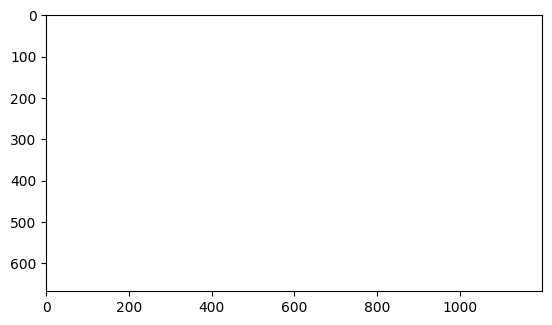

In [21]:
import cv2
import matplotlib.pyplot as plt
corr = cv2.filter2D(images[0], ddepth=-1, kernel=images[-1][:,:,0])
plt.imshow(corr)